# 01 — Synthetic Data Generation & EDA

**Nuwara Eliya landslide prototype** — Walapane, Ambagamuwa, Kotmale

> ⚠️ **All data generated in this notebook is SYNTHETIC / EXAMPLE data.** It stands in
> for real datasets (NBRO landslide inventory, Survey Dept. DEM, Dept. of Agriculture
> soil maps, Dept. of Meteorology rainfall) that are still being requested. Value ranges
> are anchored to NBRO thresholds and general highlands climatology — see
> `src/landslide_toy/config.py` for every assumption and its rationale.

This notebook generates one synthetic site table for the three DS divisions, assigns a
binary `landslide_occurred` label from an independent latent hazard process (see
`labeling.py`), saves it to `data/synthetic/`, and runs exploratory checks.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from landslide_toy import config, data_generation, labeling, viz

viz.set_style()
pd.set_option("display.max_columns", 50)


## 1. Generate synthetic sites

In [2]:
sites = data_generation.generate_sites(seed=config.SEED, n_per_division=config.N_PER_DIVISION)
sites = labeling.add_labels(sites, seed=config.SEED)
print(sites.shape)
sites.head()


(450, 17)


,site_id,division,soil_type,soil_weight,rainfall_annual_mm,max_24h_rainfall_mm,rainfall_alert_level,slope_deg,slope_band,historical_failure_count_20yr,historical_failure_density_per_km2,days_since_last_failure,slope_risk,latent_l,true_hazard_z,hazard_probability,landslide_occurred
0,KOT-0107,Kotmale,Mountain Regosol,0.60,2092.721300,23.513159,No Alert,24.042648,Moderate,3,3.0,1141.808710,0.468088,0.626958,0.413915,0.098104,0
1,KOT-0144,Kotmale,Red-Yellow Podzolic,0.75,2816.868078,24.572346,No Alert,37.927049,Very High,6,6.0,1644.268810,0.930902,0.811937,0.646346,0.526436,0
2,WAL-0117,Walapane,Reddish-Brown Latosolic,0.35,2303.814745,36.916168,No Alert,20.903323,Moderate,1,1.0,80.421672,0.363444,0.577055,0.281584,0.028146,0
3,WAL-0030,Walapane,Reddish-Brown Latosolic,0.35,1964.408502,46.823615,No Alert,17.706893,Moderate,1,1.0,4394.577834,0.256896,0.331874,0.190872,0.011556,0
4,KOT-0115,Kotmale,Mountain Regosol,0.60,2246.736874,111.649643,Alert,29.607091,High,1,1.0,6122.051084,0.653570,0.324047,0.445700,0.130038,0


## 2. Save to CSV

In [3]:
out_path = ROOT / "data" / "synthetic" / "nuwara_eliya_synthetic_sites.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
sites.to_csv(out_path, index=False)
print(f"Saved {len(sites)} rows x {sites.shape[1]} columns to {out_path}")


Saved 450 rows x 17 columns to C:\Users\Sadumina Rathnayaka\Desktop\Reserach Dummy\data\synthetic\nuwara_eliya_synthetic_sites.csv


## 3. Sanity checks

In [4]:
assert sites.isna().sum().sum() == 0, "unexpected NaNs in synthetic data"
assert len(sites) == config.N_PER_DIVISION * len(config.DIVISIONS)

print("Rows per division:")
print(sites["division"].value_counts())

print("\nClass balance (landslide_occurred):")
print(sites["landslide_occurred"].value_counts(normalize=True).round(3))

print("\nClass balance by division:")
print(sites.groupby("division")["landslide_occurred"].mean().round(3))


Rows per division:
division
Kotmale       150
Walapane      150
Ambagamuwa    150
Name: count, dtype: int64

Class balance (landslide_occurred):
landslide_occurred
0    0.793
1    0.207
Name: proportion, dtype: float64

Class balance by division:
division
Ambagamuwa    0.233
Kotmale       0.240
Walapane      0.147
Name: landslide_occurred, dtype: float64


## 4. Exploratory plots

Note: `latent_l`, `true_hazard_z`, and `hazard_probability` are kept in this table only
for transparency about how labels were generated — they are **not observable in
reality** and must never be used as model features in notebook 02.

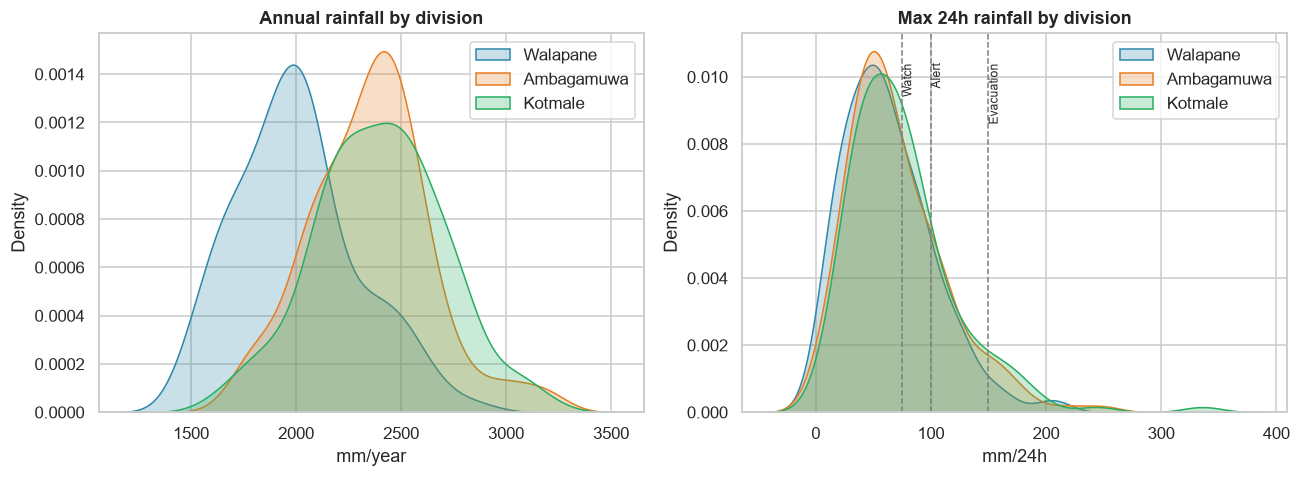

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for div, color in viz.DIVISION_COLORS.items():
    subset = sites[sites["division"] == div]
    sns.kdeplot(subset["rainfall_annual_mm"], ax=axes[0], label=div, color=color, fill=True, alpha=0.25)
    sns.kdeplot(subset["max_24h_rainfall_mm"], ax=axes[1], label=div, color=color, fill=True, alpha=0.25)

axes[0].set_title("Annual rainfall by division")
axes[0].set_xlabel("mm/year")
axes[1].set_title("Max 24h rainfall by division")
axes[1].set_xlabel("mm/24h")
for th, lbl in [(config.RAINFALL_WATCH_MM, "Watch"), (config.RAINFALL_ALERT_MM, "Alert"), (config.RAINFALL_EVACUATION_MM, "Evacuation")]:
    axes[1].axvline(th, color="gray", linestyle="--", linewidth=1)
    axes[1].text(th, axes[1].get_ylim()[1] * 0.92, lbl, rotation=90, fontsize=8, va="top")
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()


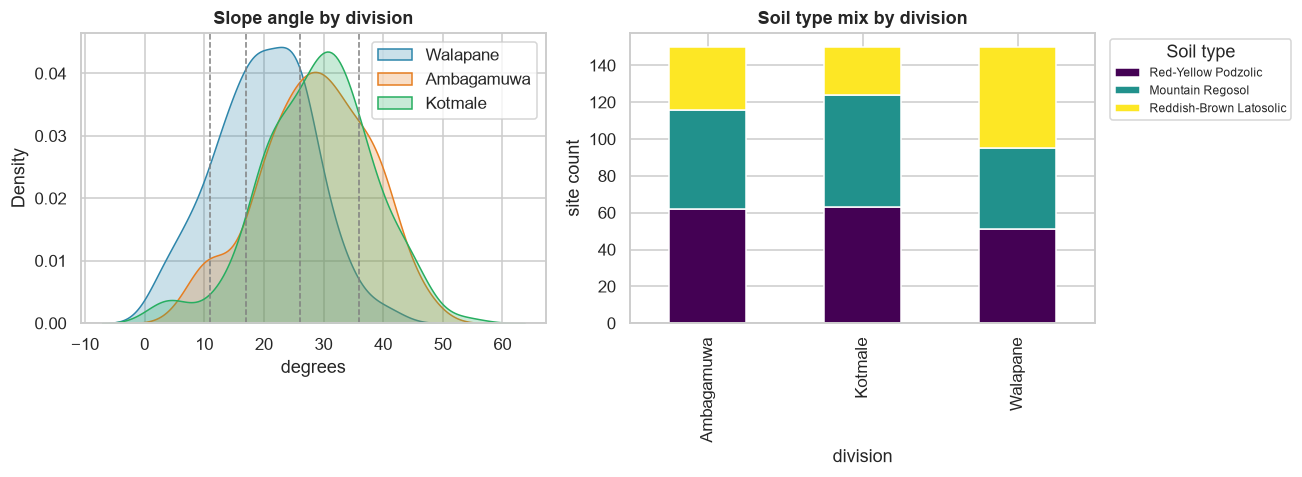

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for div, color in viz.DIVISION_COLORS.items():
    subset = sites[sites["division"] == div]
    sns.kdeplot(subset["slope_deg"], ax=axes[0], label=div, color=color, fill=True, alpha=0.25)

axes[0].set_title("Slope angle by division")
axes[0].set_xlabel("degrees")
for lo, hi, label in config.SLOPE_BANDS[1:]:
    axes[0].axvline(lo, color="gray", linestyle="--", linewidth=1)
axes[0].legend()

soil_counts = sites.groupby(["division", "soil_type"]).size().unstack(fill_value=0)
soil_counts = soil_counts[list(config.SOIL_TYPES.keys())]
soil_counts.plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Soil type mix by division")
axes[1].set_ylabel("site count")
axes[1].legend(title="Soil type", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


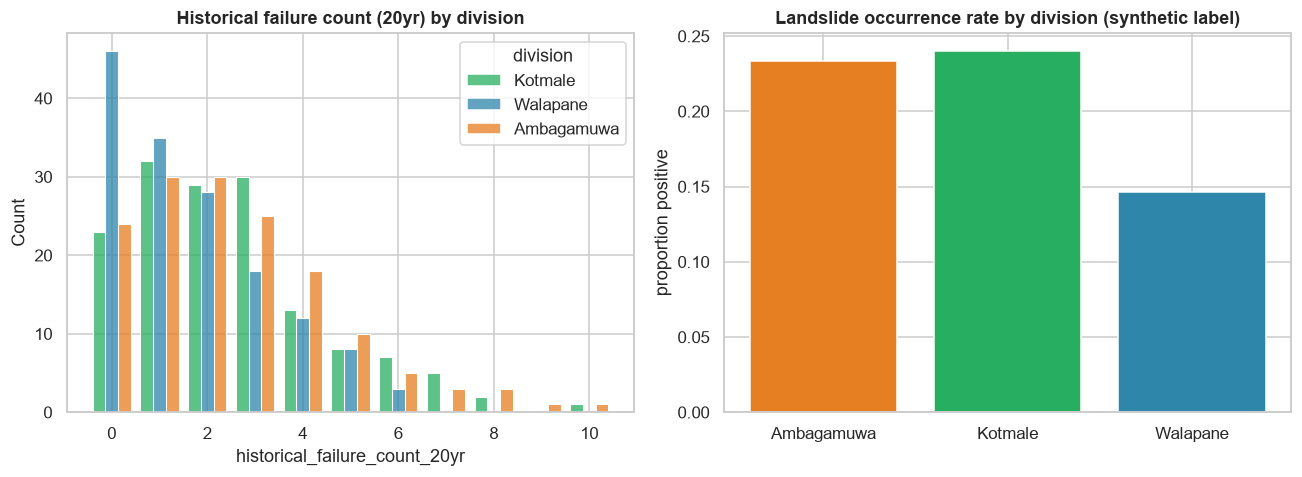

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(sites, x="historical_failure_count_20yr", hue="division", multiple="dodge",
             palette=viz.DIVISION_COLORS, ax=axes[0], discrete=True, shrink=0.8)
axes[0].set_title("Historical failure count (20yr) by division")

occurrence_rate = sites.groupby("division")["landslide_occurred"].mean()
axes[1].bar(occurrence_rate.index, occurrence_rate.values,
            color=[viz.DIVISION_COLORS[d] for d in occurrence_rate.index])
axes[1].set_title("Landslide occurrence rate by division (synthetic label)")
axes[1].set_ylabel("proportion positive")
plt.tight_layout()
plt.show()


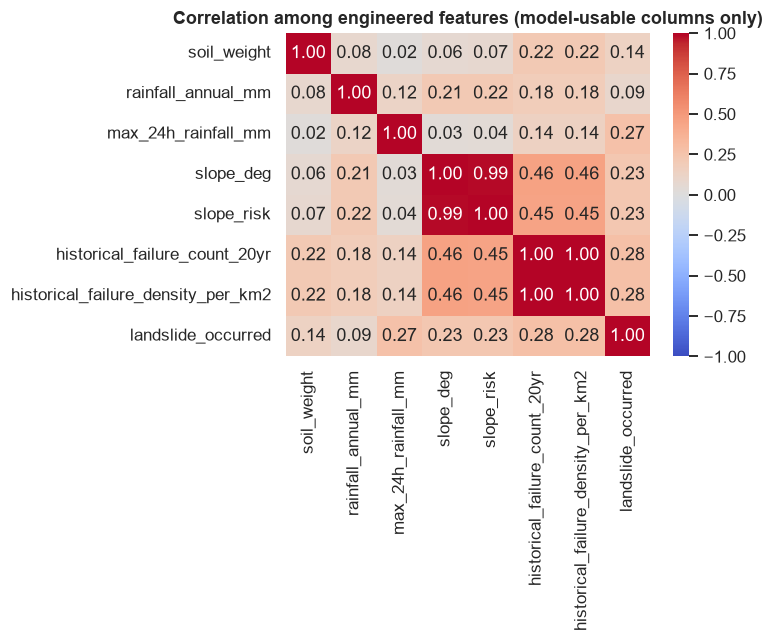

In [8]:
numeric_cols = [
    "soil_weight", "rainfall_annual_mm", "max_24h_rainfall_mm", "slope_deg", "slope_risk",
    "historical_failure_count_20yr", "historical_failure_density_per_km2",
    "landslide_occurred",
]
corr = sites[numeric_cols].corr()
plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation among engineered features (model-usable columns only)")
plt.tight_layout()
plt.show()


## 5. Takeaways

- 450 synthetic sites generated (150 per division), no missing values.
- Class balance is close to the ~22% target prevalence set in `config.TARGET_PREVALENCE`
  (a deliberately rare-event style imbalance, not 50/50).
- Kotmale/Ambagamuwa show steeper slopes and wetter rainfall than Walapane, by
  construction — this reflects the assumed climatology in `config.py`, not a measurement.
- Historical failure counts correlate with slope/soil as designed, but also carry the
  latent factor `L` that slope+soil alone cannot see — this is the mechanism notebook 02
  tests.

**Next:** `02_model_comparison.ipynb` trains XGBoost and LightGBM on Feature Set A
(soil+rainfall+history) vs Feature Set B (soil+rainfall+slope) and compares them fairly.